In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. read in data

In [2]:
df_two = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/double_slit.csv')
df_left = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/position_2_singleslit.csv')
df_right = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/position_4_single_slit.csv')

In [3]:
x_pos3, V_pos3 = df_two.x, df_two.voltage
x_pos2, V_pos2 = df_left.x, df_left.voltage
x_pos4, V_pos4 = df_right['x (mm)'], df_right.voltage

(2.0, 6.0)

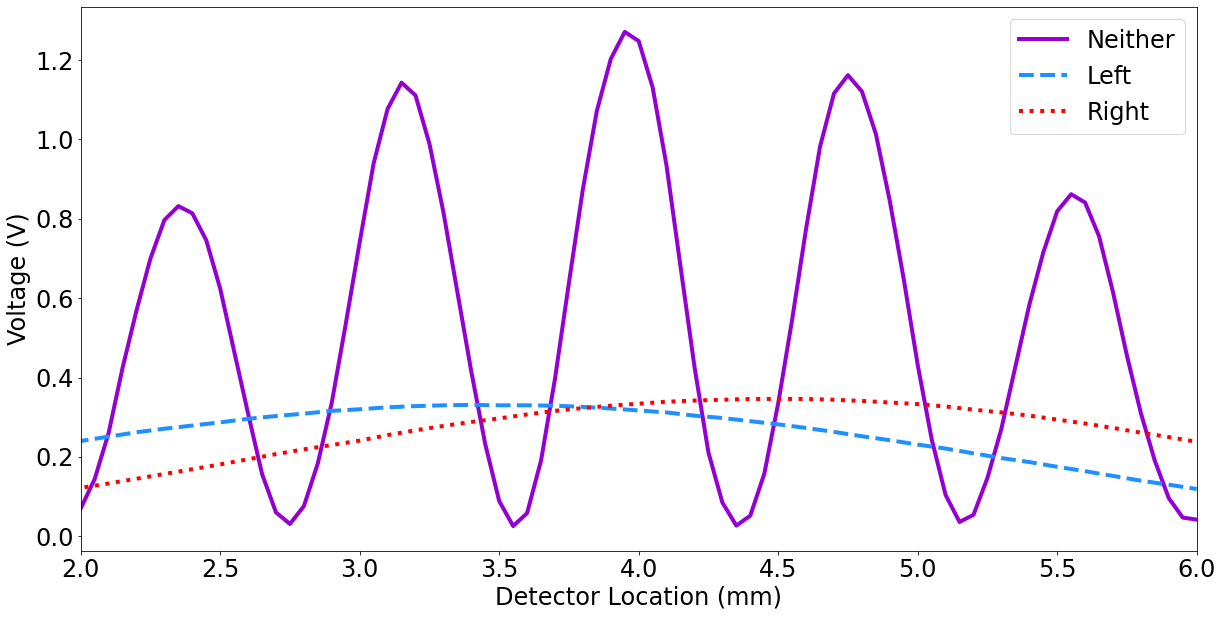

In [4]:
fig = plt.figure(figsize=(20,10))
fs = 24

plt.plot(x_pos3, V_pos3, label='Neither', c='darkviolet', linewidth=4)
plt.plot(x_pos2, V_pos2, ls='--', label='Left', c='dodgerblue',linewidth=4)
plt.plot(x_pos4, V_pos4, ls=':', label='Right', c='red',linewidth=4)
plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(2,6)

## Fit the data

In [5]:
from scipy.optimize import curve_fit

In [6]:
def I_single(x, A, x_o, I_o):
    return I_o * (np.sin(A * (x - x_o)) / (A * (x - x_o)))**2.

In [7]:
popt_sing_pos2, popt_cov_sing_pos2 = curve_fit(I_single, x_pos2, V_pos2, bounds=([0,np.inf]))

popt_sing_pos4, popt_cov_sing_pos4 = curve_fit(I_single, x_pos4, V_pos4, bounds=([0,np.inf]))

errors_pos2 = np.sqrt(np.diag(popt_cov_sing_pos2))
errors_pos4 = np.sqrt(np.diag(popt_cov_sing_pos4))

In [8]:
params = ["A", "x_o", "I_o"]
for i in range(3):
    print(params[i])
    print(round(popt_sing_pos2[i],5), '+/-', round(errors_pos2[i],5))
    print(round(popt_sing_pos4[i],5), '+/-', round(errors_pos4[i],5))

A
0.6568 +/- 0.00092
0.67885 +/- 0.00148
x_o
3.46252 +/- 0.00187
4.47835 +/- 0.00293
I_o
0.3303 +/- 0.00021
0.34598 +/- 0.00035


(1.8, 6.1)

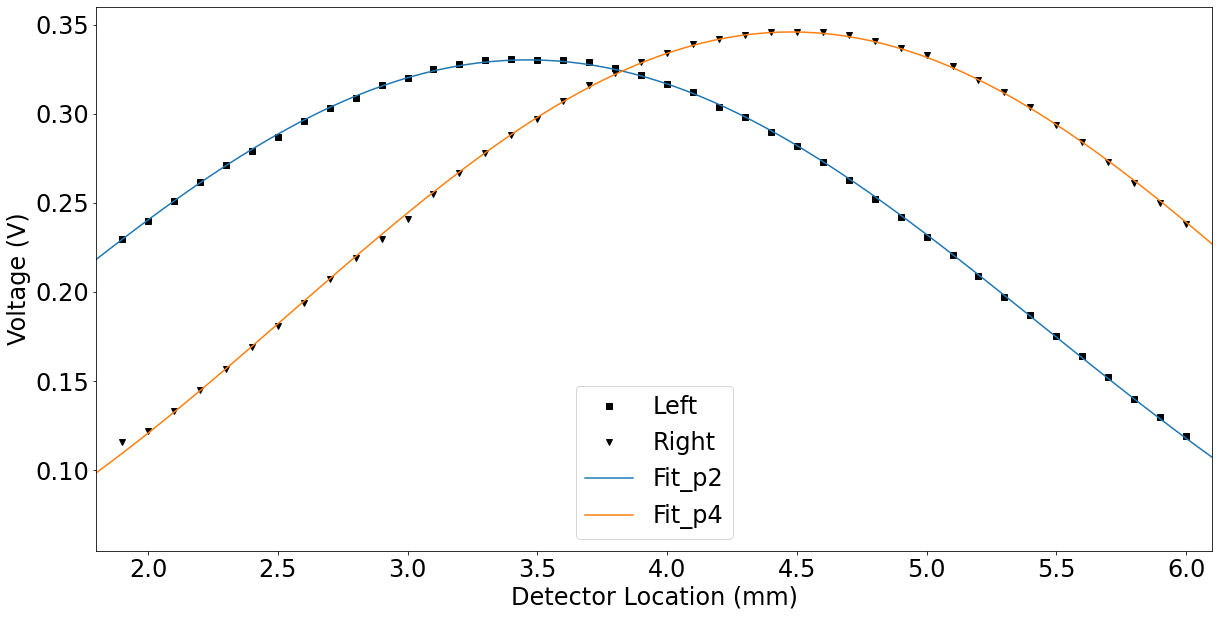

In [9]:
fig = plt.figure(figsize=(20,10))
fs = 24

plt.plot(x_pos2, V_pos2, 'sk', label='Left')
plt.plot(x_pos4, V_pos4, 'vk', label='Right')

xarr = np.linspace(1.5,6.5,100)
plt.plot(xarr, I_single(xarr, popt_sing_pos2[0], popt_sing_pos2[1], popt_sing_pos2[2]), label='Fit_p2')
plt.plot(xarr, I_single(xarr, popt_sing_pos4[0], popt_sing_pos4[1], popt_sing_pos4[2]), label='Fit_p4')


plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

Recall that
$A = \frac{\pi a}{\lambda D}$

In [10]:
# laser wavelength and error
lam, lam_err = 670., 5.                # nm
lam, lam_err = lam*1e-6, lam_err*1e-6  # mm

# length of box and error
D, D_err = 1.005, 0.00025     # m
D, D_err = D*1e3, D_err*1e3  # mm

sovle for slit width $a$ and the uncertainty for each slit

In [11]:
def calc_param(wv, dist, p):
    return wv * dist * p / np.pi

def calc_param_err(wv, dist, param, err_wv, err_dist, err_param):
    wv_contr = (dist * param / np.pi)**2. * err_wv**2.
    D_contr = (wv * param / np.pi)**2. * err_dist**2.
    param_contr = (wv * dist / np.pi)**2. * err_param**2.
    
    return np.sqrt(wv_contr + D_contr + param_contr)

In [12]:
# solve for slit width
a_left = calc_param(lam, D, popt_sing_pos2[0])
a_right = calc_param(lam, D, popt_sing_pos4[0])

# propagate the error by adding uncertainties in quadrature
a_left_err = calc_param_err(lam, D, popt_sing_pos2[0], lam_err, D_err, errors_pos2[0]) 
a_right_err = calc_param_err(lam, D, popt_sing_pos4[0], lam_err, D_err, errors_pos4[0]) 

In [24]:
a_meas = np.average((a_left, a_right),weights=(a_left_err,a_right_err))
a_meas_err = np.sqrt(a_left_err**2. + a_right_err**2.)
print(a_meas, a_meas_err)

0.14320461265458548 0.0015573853310070526


## Now solve for slit separation $b$ and its uncertainty

Recall that $B = \frac{\pi b}{\lambda D}$

In [14]:
A_meas = np.average((popt_sing_pos2[0], popt_sing_pos4[0]),weights=(errors_pos2[0],errors_pos4[0]))
print(A_meas)

x_o_meas = np.average((popt_sing_pos2[1], popt_sing_pos4[1]),weights=(errors_pos2[1],errors_pos4[1]))
print(x_o_meas)

I_o_meas = np.average((popt_sing_pos2[2], popt_sing_pos4[2]),weights=(errors_pos2[2],errors_pos4[2]))
print(I_o_meas)

0.6703788227531867
4.083093482426996
0.3401499028232439


In [15]:
b_guess = 0.457 # mm guess
B_guess = np.pi * b_guess / (lam * 0.5*1e3)
print(B_guess)

4.285695052807569


In [16]:
def I_double(x, B, A, Io, xo):
    return Io * ((np.sin(A * (x - xo)))**2. / (A * (x - xo))**2.) * (np.cos(B * (x - xo)))**2.

In [17]:
popt_doub, popt_cov_doub = curve_fit(I_double, x_pos3, V_pos3, p0=[B_guess, A_meas, 1.2, x_o_meas],)#bounds=([1.85, 0.5, 0.31775, 3.8], [4., 1.0, 0.4, 4.1]))
errors_doub = np.sqrt(np.diag(popt_cov_doub))


(1.8, 6.1)

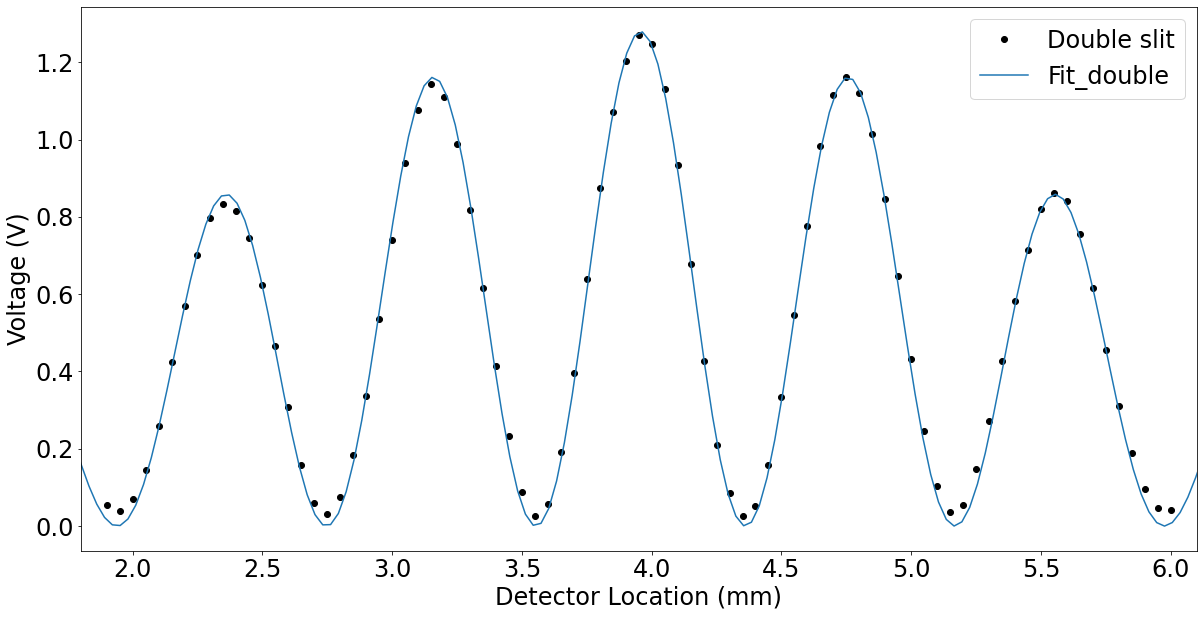

In [18]:
fig = plt.figure(figsize=(20,10))
fs = 24

plt.plot(x_pos3, V_pos3, 'ok', label='Double slit')

xarr = np.linspace(-10,20,1000)
plt.plot(xarr, I_double(xarr, popt_doub[0], popt_doub[1], popt_doub[2], popt_doub[3]), label='Fit_double')


plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

In [20]:
# solve for slit separation
b_meas = calc_param(lam, D, popt_doub[0])
b_meas_err = calc_param_err(lam, D, popt_doub[0], lam_err, D_err, errors_doub[0]) 

print(b_meas, b_meas_err)

0.8342680864807986 0.006274372027328393


## Notes

* use the single slit parameters as the guesses for double slit